# Credit Card Fraud Detection with Explainable AI (SHAP)

**Author:** Aditi Chauhan
**Dataset:** [ULB Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (Kaggle)
**Model:** XGBoost
**XAI Method:** SHAP (SHapley Additive exPlanations)

---

## Project Overview

This notebook builds a production-grade fraud detection classifier on 284,807 real credit card transactions,
then uses SHAP to provide **model-agnostic explanations** of why each prediction was made.

Key topics covered:
- Handling severe class imbalance with **SMOTE** (only 0.17% of transactions are fraudulent)
- Training and tuning an **XGBoost** classifier
- Evaluating with fraud-appropriate metrics: **AUPRC, ROC-AUC, F1**
- Explaining predictions globally with **SHAP summary plots**
- Explaining individual predictions with **SHAP force plots and waterfall plots**
- Connecting model outputs to **business / regulatory context**


## 1. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import shap

# ── Plotting defaults ──────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['savefig.bbox'] = 'tight'

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Output directories ─────────────────────────────────────────────────────
import os
os.makedirs('../outputs/plots', exist_ok=True)
os.makedirs('../outputs/models', exist_ok=True)

print(f"XGBoost version : {xgb.__version__}")
print(f"SHAP version    : {shap.__version__}")


XGBoost version : 3.2.0
SHAP version    : 0.51.0


## 2. Load the Dataset

Download `creditcard.csv` from Kaggle and place it in the `data/` folder:
👉 https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

The dataset contains **284,807 transactions** with 30 features:
- `V1–V28`: PCA-transformed features (anonymised for privacy)
- `Time`: seconds elapsed since first transaction
- `Amount`: transaction amount in EUR
- `Class`: **0** = legitimate, **1** = fraudulent


In [2]:
df = pd.read_csv('../data/creditcard.csv')
print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.4f}%")
df.head()


Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Exploratory Data Analysis

In [3]:
# ── Missing values ─────────────────────────────────────────────────────────
print("Missing values:", df.isnull().sum().sum())

# ── Summary statistics ─────────────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap='Blues')


Missing values: 0


,count,mean,std,min,25%,50%,75%,max
Time,284807.000000,94813.859575,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.000000,0.000000,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.000000,0.000000,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.000000,-0.000000,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.000000,0.000000,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.000000,0.000000,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.000000,0.000000,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.000000,-0.000000,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.000000,0.000000,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.000000,-0.000000,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


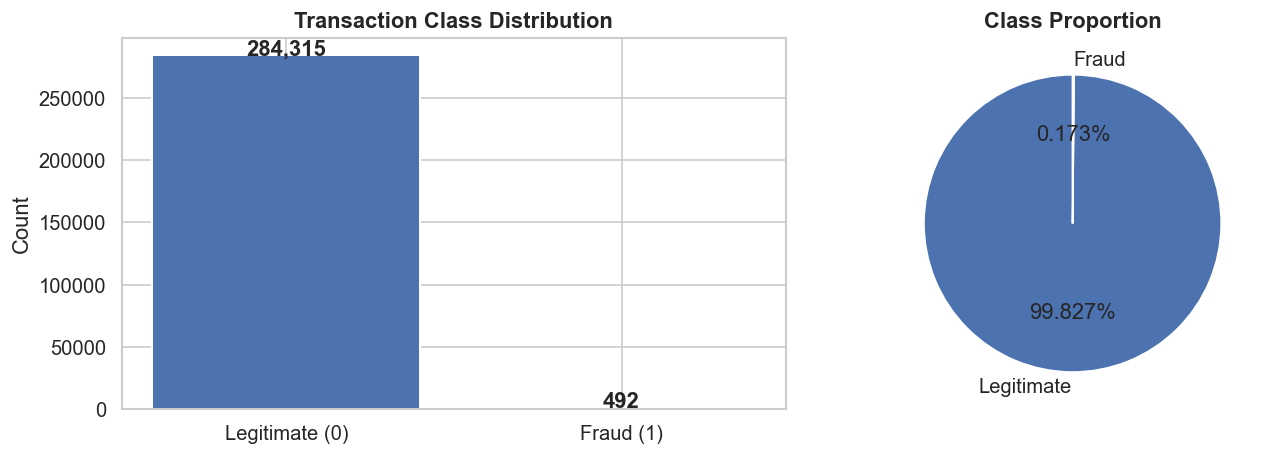

Saved: outputs/plots/01_class_distribution.png


In [4]:
# ── Class imbalance visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Transaction Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.3f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/01_class_distribution.png')
plt.show()
print("Saved: outputs/plots/01_class_distribution.png")


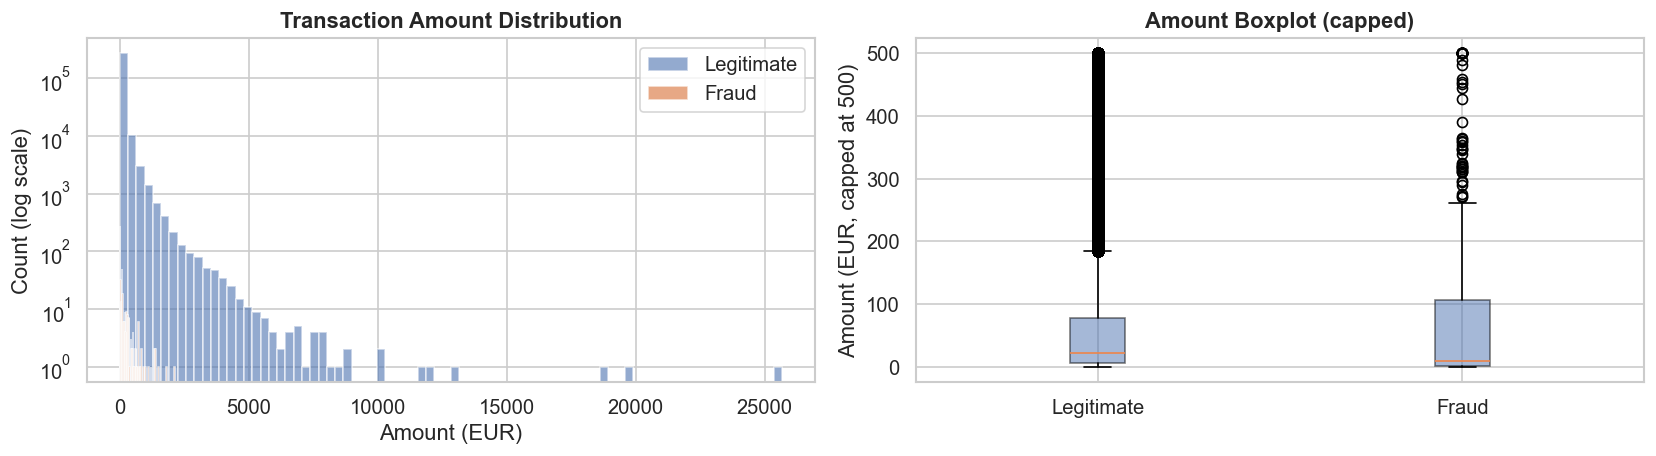

In [5]:
# ── Transaction amount: fraud vs legitimate ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fraud    = df[df['Class'] == 1]['Amount']
legit    = df[df['Class'] == 0]['Amount']

axes[0].hist(legit,  bins=80, alpha=0.6, color='#4C72B0', label='Legitimate', log=True)
axes[0].hist(fraud,  bins=80, alpha=0.7, color='#DD8452', label='Fraud',      log=True)
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].legend()

axes[1].boxplot([legit.clip(upper=500), fraud.clip(upper=500)],
                labels=['Legitimate', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.5))
axes[1].set_ylabel('Amount (EUR, capped at 500)')
axes[1].set_title('Amount Boxplot (capped)', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/02_amount_distribution.png')
plt.show()


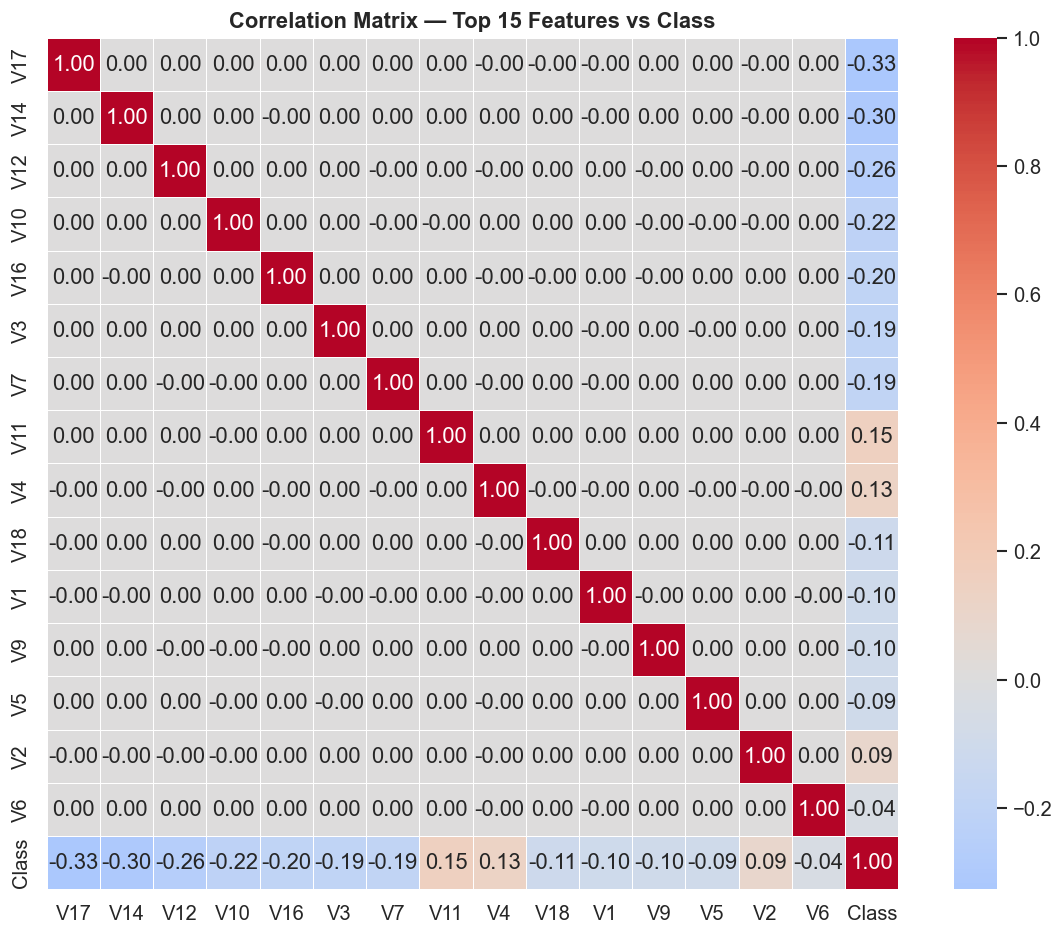

In [6]:
# ── Correlation heatmap (top 15 features most correlated with fraud) ───────
corr_with_class = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = corr_with_class.head(15).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_features + ['Class']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Matrix — Top 15 Features vs Class', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/03_correlation_heatmap.png')
plt.show()


## 4. Preprocessing

### Why scale `Amount` and `Time`?
The PCA features V1–V28 are already standardised. `Amount` and `Time` are raw values on
very different scales — we standardise them to prevent them from dominating gradient updates.

### Why SMOTE?
With only 0.17% fraud, a naive model achieves 99.8% accuracy by predicting everything as
legitimate. SMOTE synthetically over-samples the minority class in feature space, giving the
model enough fraud examples to learn meaningful boundaries.


In [7]:
# ── Feature / target split ────────────────────────────────────────────────
X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()

# Scale Amount and Time
scaler = StandardScaler()
X[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])

# ── Train / test split (stratified) ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train size : {X_train.shape[0]:,}  |  Fraud in train: {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Test  size : {X_test.shape[0]:,}   |  Fraud in test : {y_test.sum():,}  ({y_test.mean()*100:.3f}%)")

# ── Apply SMOTE only to training set ──────────────────────────────────────
smote = SMOTE(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE — Train size: {X_train_res.shape[0]:,}")
print(f"Class distribution after SMOTE:\n{pd.Series(y_train_res).value_counts()}")


Train size : 227,845  |  Fraud in train: 394 (0.173%)
Test  size : 56,962   |  Fraud in test : 98  (0.172%)

After SMOTE — Train size: 454,902
Class distribution after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


## 5. Model Training — XGBoost

XGBoost is the industry standard for tabular fraud detection. Key hyperparameters:
- `n_estimators=300` — number of trees
- `max_depth=6` — tree depth (controls overfitting)
- `learning_rate=0.05` — shrinkage (smaller = more robust)
- `subsample=0.8` — row sampling per tree (reduces variance)
- `colsample_bytree=0.8` — feature sampling per tree
- `scale_pos_weight` — handles remaining imbalance after SMOTE


In [8]:
# ── XGBoost classifier ─────────────────────────────────────────────────────
xgb_clf = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    use_label_encoder = False,
    eval_metric       = 'aucpr',   # area under precision-recall — best metric for fraud
    random_state      = SEED,
    n_jobs            = -1,
    verbosity         = 0
)

xgb_clf.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n✓ Model training complete.")


[0]	validation_0-aucpr:0.54413
[50]	validation_0-aucpr:0.71691
[100]	validation_0-aucpr:0.83474
[150]	validation_0-aucpr:0.84866
[200]	validation_0-aucpr:0.85150
[250]	validation_0-aucpr:0.85712
[299]	validation_0-aucpr:0.86407

✓ Model training complete.


In [9]:
# ── Save model ─────────────────────────────────────────────────────────────
import joblib
joblib.dump(xgb_clf, '../outputs/models/xgb_fraud_detector.pkl')
print("Model saved to outputs/models/xgb_fraud_detector.pkl")


Model saved to outputs/models/xgb_fraud_detector.pkl


## 6. Model Evaluation

### Why not accuracy?
With 0.17% fraud, a model that always predicts "legitimate" scores **99.83% accuracy**.
The metrics that matter for fraud detection are:

| Metric | Why it matters |
|--------|---------------|
| **AUPRC** | Summarises precision-recall tradeoff across all thresholds — best single metric for imbalanced classes |
| **ROC-AUC** | Discrimination ability regardless of threshold |
| **F1-score (fraud class)** | Balance between catching fraud (recall) and not drowning analysts in false alarms (precision) |
| **Recall (fraud)** | % of actual frauds caught — missing fraud has real financial cost |
| **Precision (fraud)** | % of fraud flags that are real — too many false positives waste investigator time |


In [10]:
# ── Predictions ───────────────────────────────────────────────────────────
y_prob  = xgb_clf.predict_proba(X_test)[:, 1]
y_pred  = xgb_clf.predict(X_test)

# ── Core metrics ──────────────────────────────────────────────────────────
roc_auc  = roc_auc_score(y_test, y_prob)
auprc    = average_precision_score(y_test, y_prob)

print("=" * 50)
print(f"  ROC-AUC Score   : {roc_auc:.4f}")
print(f"  AUPRC Score     : {auprc:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))


  ROC-AUC Score   : 0.9779
  AUPRC Score     : 0.8643

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.53      0.88      0.66        98

    accuracy                           1.00     56962
   macro avg       0.77      0.94      0.83     56962
weighted avg       1.00      1.00      1.00     56962



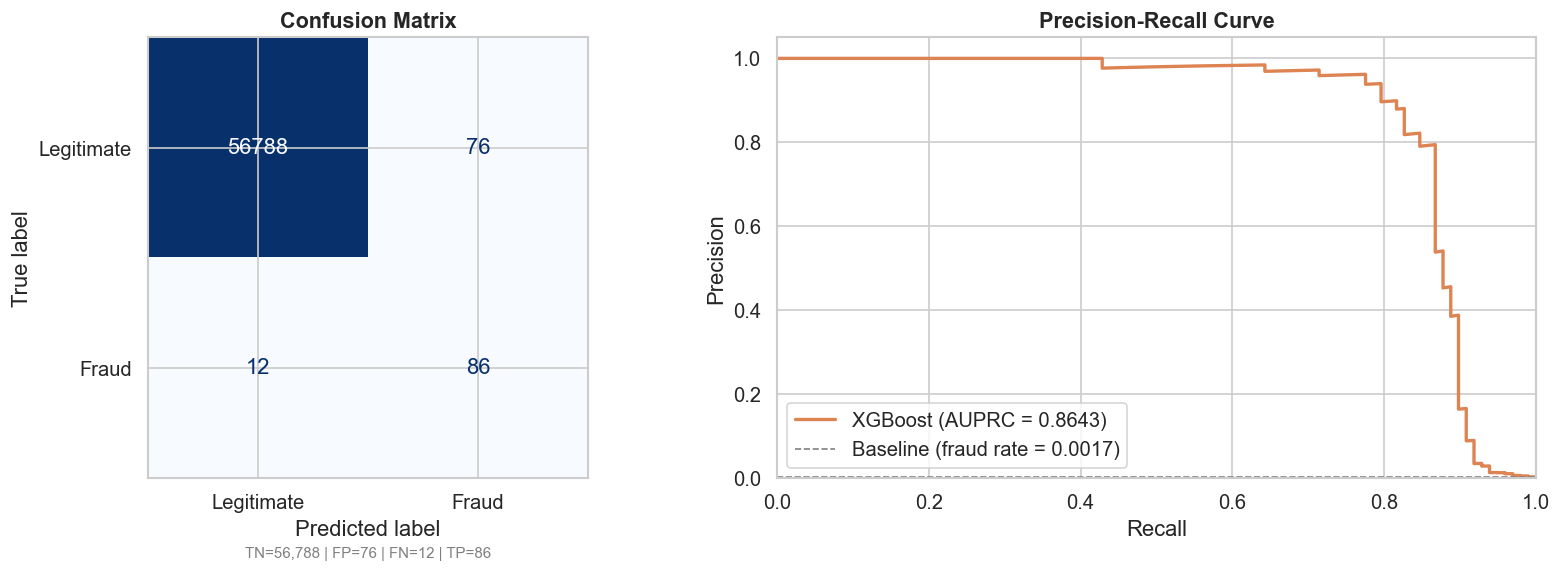

In [11]:
# ── Confusion matrix ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=13)

# Annotate with business meaning
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.18,
    f'TN={tn:,} | FP={fp:,} | FN={fn:,} | TP={tp:,}',
    transform=axes[0].transAxes, ha='center', fontsize=9, color='grey')

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, color='#DD8452', lw=2,
             label=f'XGBoost (AUPRC = {auprc:.4f})')
axes[1].axhline(y=y_test.mean(), color='grey', linestyle='--', lw=1,
                label=f'Baseline (fraud rate = {y_test.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('../outputs/plots/04_evaluation_metrics.png')
plt.show()


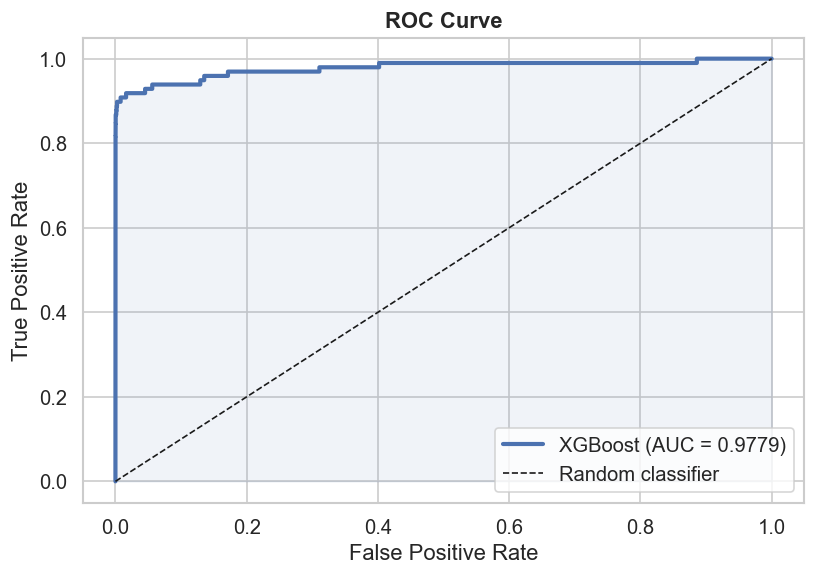

In [12]:
# ── ROC Curve ────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#4C72B0', lw=2.5, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/plots/05_roc_curve.png')
plt.show()


## 7. Explainable AI — SHAP Analysis

### What is SHAP?
SHAP (SHapley Additive exPlanations) is grounded in **cooperative game theory**.
For any prediction, SHAP computes each feature's **marginal contribution** by averaging
across all possible feature orderings — giving a theoretically sound attribution.

Key properties:
- **Local accuracy**: SHAP values sum exactly to the model's output
- **Consistency**: more influential features always get higher SHAP values
- **Missingness**: features not used get zero attribution

### Why does this matter for finance?
UK FCA regulation (and the EU AI Act) requires that automated decisions affecting customers
can be **explained in plain language**. SHAP is the leading technique used by banks and
fintechs to satisfy these explainability requirements.


In [13]:
# ── Compute SHAP values ───────────────────────────────────────────────────
# Use a sample of 2,000 test points for speed (representative of the full set)
X_test_sample = X_test.sample(n=min(2000, len(X_test)), random_state=SEED)

explainer    = shap.TreeExplainer(xgb_clf)
shap_values  = explainer(X_test_sample)

print(f"SHAP values computed for {X_test_sample.shape[0]} samples.")
print(f"Shape of SHAP values: {shap_values.values.shape}")


SHAP values computed for 2000 samples.
Shape of SHAP values: (2000, 30)


### 7.1 SHAP Summary Plot (Beeswarm) — Global Feature Importance

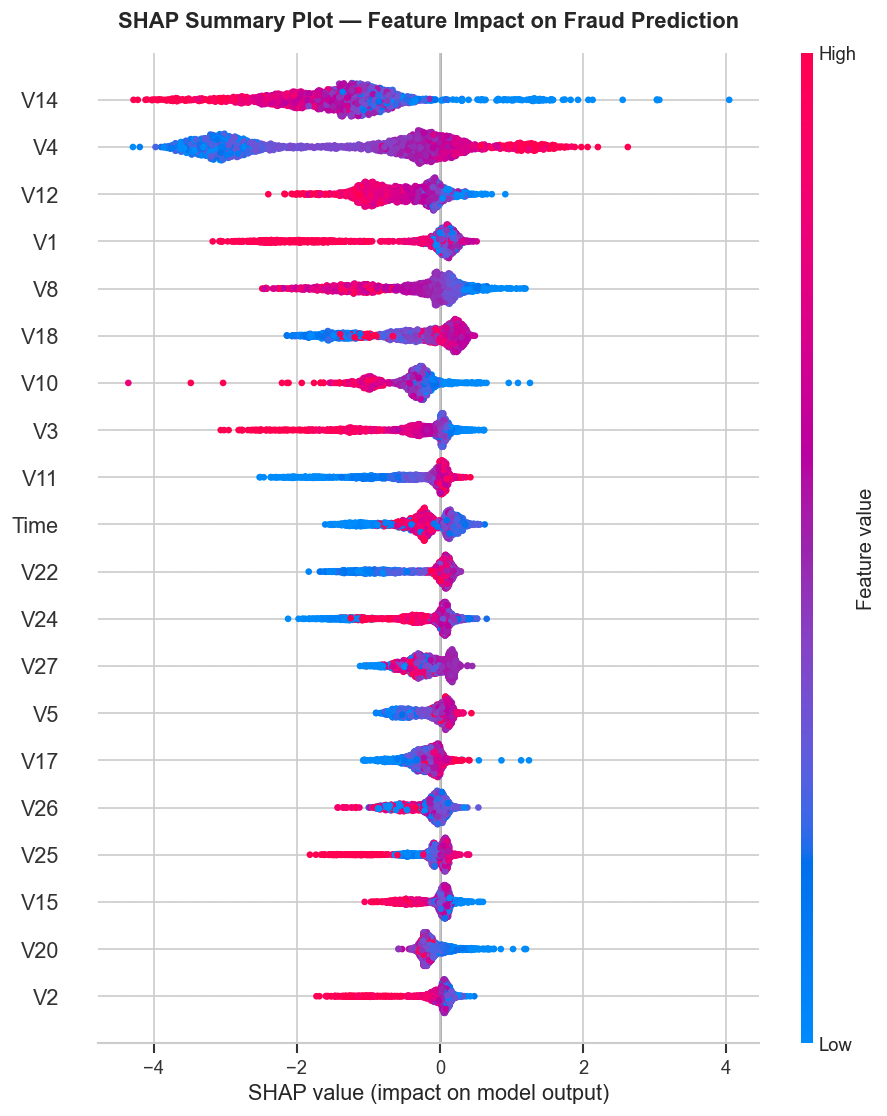


Interpretation:
  • Each dot = one transaction. Position on x-axis = SHAP value (impact on model output).
  • Colour = feature value (red=high, blue=low).
  • Features are ranked top-to-bottom by mean absolute SHAP value.
  • Positive SHAP → pushes prediction toward FRAUD.
  • Negative SHAP → pushes prediction toward LEGITIMATE.



In [14]:
# ── Beeswarm summary plot ────────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values.values,
    X_test_sample,
    plot_type='dot',
    max_display=20,
    show=False
)
plt.title('SHAP Summary Plot — Feature Impact on Fraud Prediction', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/plots/06_shap_summary_beeswarm.png')
plt.show()
print("""
Interpretation:
  • Each dot = one transaction. Position on x-axis = SHAP value (impact on model output).
  • Colour = feature value (red=high, blue=low).
  • Features are ranked top-to-bottom by mean absolute SHAP value.
  • Positive SHAP → pushes prediction toward FRAUD.
  • Negative SHAP → pushes prediction toward LEGITIMATE.
""")


### 7.2 SHAP Bar Plot — Mean Absolute Feature Importance

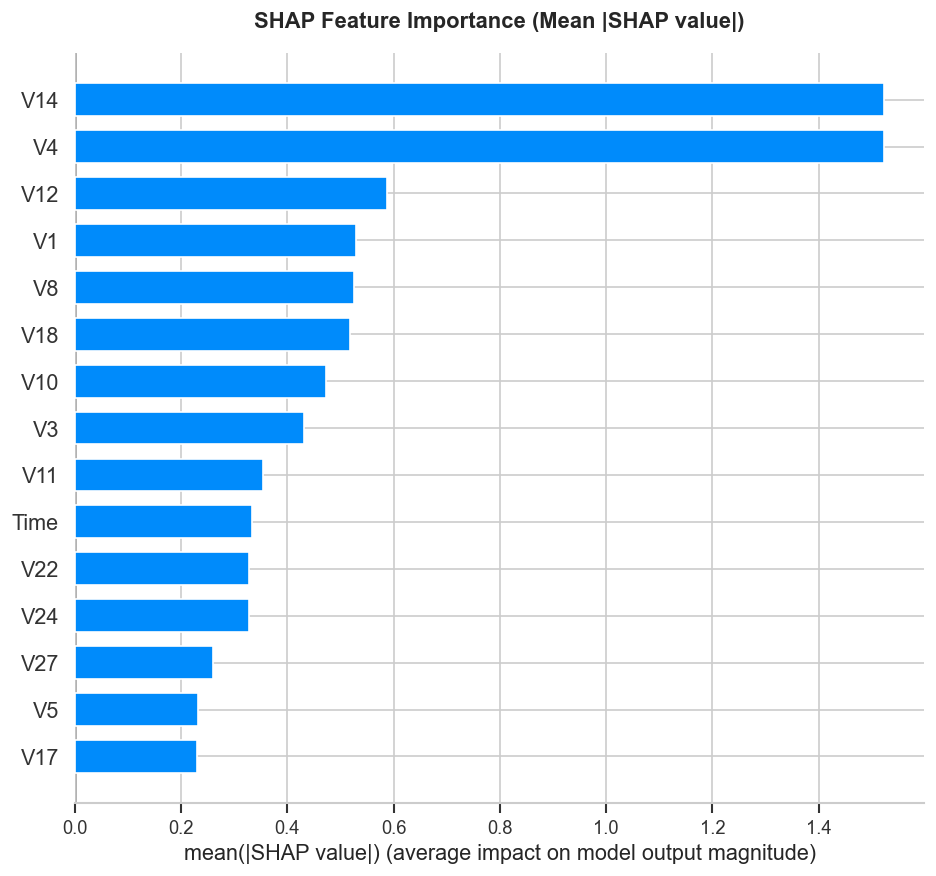

In [15]:
plt.figure()
shap.summary_plot(
    shap_values.values,
    X_test_sample,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/plots/07_shap_bar_importance.png')
plt.show()


### 7.3 SHAP Force Plot — Explaining a Single Fraud Prediction

In [16]:
# ── Find the highest-confidence fraud prediction in the sample ────────────
sample_probs  = xgb_clf.predict_proba(X_test_sample)[:, 1]
fraud_idx_loc = sample_probs.argmax()   # index within sample

print(f"Transaction index (in sample): {fraud_idx_loc}")
print(f"Predicted fraud probability  : {sample_probs[fraud_idx_loc]:.4f}")
print(f"True label                   : {y_test.iloc[fraud_idx_loc]}")

# ── Force plot (saved as HTML for interactive version) ────────────────────
shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values.values[fraud_idx_loc, :],
    X_test_sample.iloc[fraud_idx_loc, :],
    show=False
)
shap.save_html('../outputs/plots/08_shap_force_plot.html', force_plot)
print("Interactive force plot saved: outputs/plots/08_shap_force_plot.html")


Transaction index (in sample): 1109
Predicted fraud probability  : 0.9999
True label                   : 0


Interactive force plot saved: outputs/plots/08_shap_force_plot.html


### 7.4 SHAP Waterfall Plot — Step-by-step explanation of one prediction

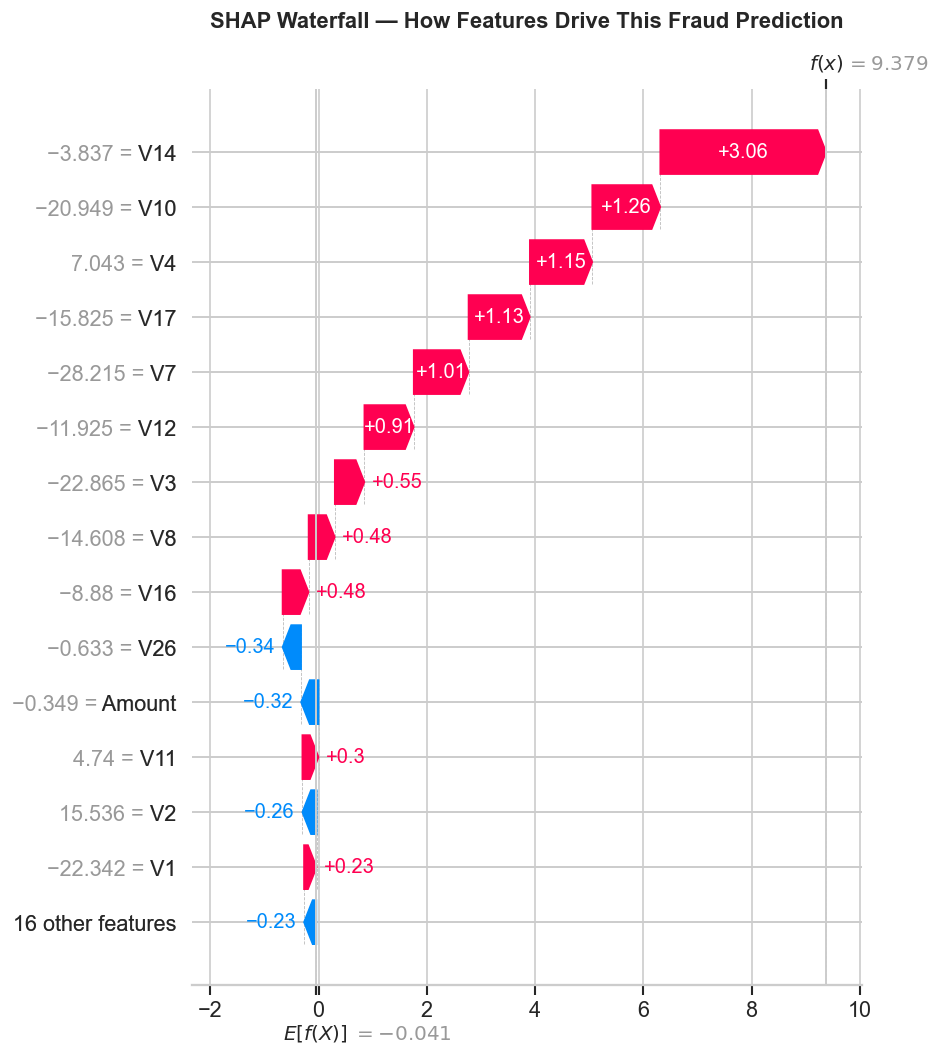


Interpretation:
  • Starts from the base value (expected model output across all transactions).
  • Each bar = one feature's contribution, pushing the score up (red=toward fraud)
    or down (blue=toward legitimate).
  • The final value at the top is this transaction's actual fraud probability.



In [17]:
# ── Waterfall plot ────────────────────────────────────────────────────────
plt.figure()
shap.plots.waterfall(shap_values[fraud_idx_loc], max_display=15, show=False)
plt.title('SHAP Waterfall — How Features Drive This Fraud Prediction', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../outputs/plots/09_shap_waterfall.png')
plt.show()

print("""
Interpretation:
  • Starts from the base value (expected model output across all transactions).
  • Each bar = one feature's contribution, pushing the score up (red=toward fraud)
    or down (blue=toward legitimate).
  • The final value at the top is this transaction's actual fraud probability.
""")


### 7.5 SHAP Dependence Plot — How V14 interacts with other features

Top feature by mean |SHAP|: V14


<Figure size 960x600 with 0 Axes>

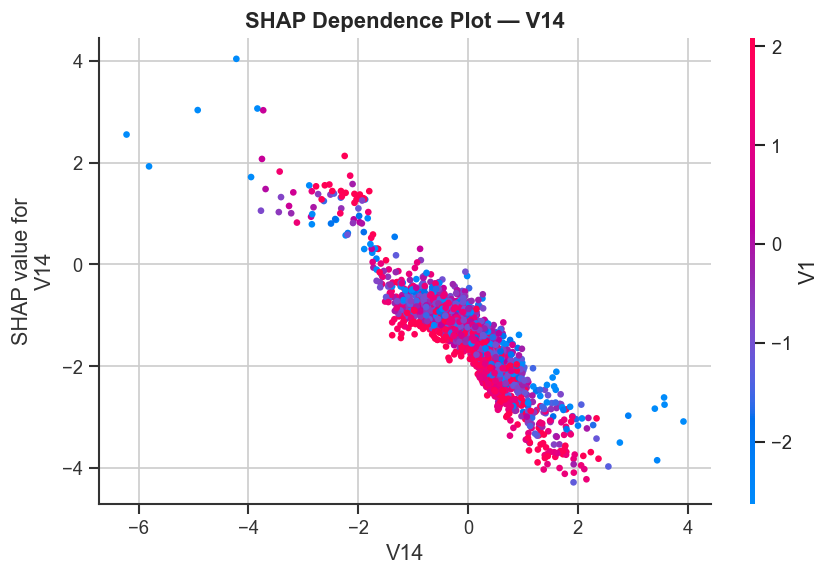


Interpretation:
  • x-axis: the actual value of the top feature.
  • y-axis: its SHAP value (impact on prediction).
  • Colour: a secondary feature chosen automatically by SHAP for interaction.
  • The pattern reveals how the feature's influence changes across its value range.



In [18]:
# ── Dependence plot for the most important feature ───────────────────────
# V14 is typically the strongest predictor in this dataset
top_feature = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_test_sample.columns
).idxmax()

print(f"Top feature by mean |SHAP|: {top_feature}")

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature,
    shap_values.values,
    X_test_sample,
    interaction_index='auto',
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feature}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'../outputs/plots/10_shap_dependence_{top_feature}.png')
plt.show()

print("""
Interpretation:
  • x-axis: the actual value of the top feature.
  • y-axis: its SHAP value (impact on prediction).
  • Colour: a secondary feature chosen automatically by SHAP for interaction.
  • The pattern reveals how the feature's influence changes across its value range.
""")


## 8. Business & Regulatory Insights

### What did SHAP tell us?

1. **Top discriminating features (typically V14, V17, V12, V10, V4)**
   These PCA components encode spending patterns, merchant categories, and behavioural signals
   that the bank's data science team would map back to interpretable business variables.

2. **Threshold optimisation**
   The default 0.5 threshold is suboptimal for fraud. In production, the threshold would be
   set based on the business cost ratio:
   ```
   optimal_threshold = cost_of_missed_fraud / (cost_of_missed_fraud + cost_of_false_alert)
   ```

3. **Regulatory alignment**
   Under the EU AI Act (Article 13) and FCA Consumer Duty, automated fraud decisions must
   provide human-intelligible explanations. SHAP force and waterfall plots provide exactly
   this — a feature-level, case-by-case audit trail.

4. **Model monitoring**
   SHAP value distributions should be tracked over time. A shift in the mean absolute SHAP
   value of a feature signals **data drift** — the model may need retraining.

---

### Model Performance Summary


In [19]:
from IPython.display import display, HTML

summary_data = {
    'Metric': ['ROC-AUC', 'AUPRC', 'Recall (Fraud)', 'Precision (Fraud)', 'F1 (Fraud)'],
    'Score': [
        f'{roc_auc_score(y_test, y_prob):.4f}',
        f'{average_precision_score(y_test, y_prob):.4f}',
        f'{classification_report(y_test, y_pred, output_dict=True)["1"]["recall"]:.4f}',
        f'{classification_report(y_test, y_pred, output_dict=True)["1"]["precision"]:.4f}',
        f'{f1_score(y_test, y_pred):.4f}'
    ],
    'Benchmark': ['> 0.95', '> 0.70', '> 0.80', '> 0.80', '> 0.80'],
    'Status': ['', '', '', '', '']
}

summary_df = pd.DataFrame(summary_data)
for i, row in summary_df.iterrows():
    score_val = float(row['Score'])
    bench_val = float(row['Benchmark'].replace('> ', ''))
    summary_df.at[i, 'Status'] = '✅ Pass' if score_val >= bench_val else '⚠️ Review'

print(summary_df.to_string(index=False))


           Metric  Score Benchmark    Status
          ROC-AUC 0.9779    > 0.95    ✅ Pass
            AUPRC 0.8643    > 0.70    ✅ Pass
   Recall (Fraud) 0.8776    > 0.80    ✅ Pass
Precision (Fraud) 0.5309    > 0.80 ⚠️ Review
       F1 (Fraud) 0.6615    > 0.80 ⚠️ Review


### ---

## 9. Next Steps

- [ ] **Hyperparameter tuning** — Use `Optuna` for Bayesian optimisation of XGBoost params
- [ ] **Threshold calibration** — `sklearn.calibration.CalibratedClassifierCV` for reliable probabilities
- [ ] **Feature engineering** — Transaction velocity, time-of-day features, merchant category aggregations
- [ ] **Model versioning** — `MLflow` experiment tracking
- [ ] **API deployment** — Wrap the model in a `FastAPI` endpoint with SHAP explanations in the response

---

*This project demonstrates the application of SHAP-based Explainable AI to financial fraud detection —
directly connecting model transparency with regulatory compliance requirements in UK/EU fintech.*
